In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
ds = pd.read_csv("dirty_cafe_sales.csv")

In [3]:
ds

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
ds.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [6]:
ds = ds.rename(columns={
    'Transaction ID':'Transaction_ID',
    'Price Per Unit':'Price_Per_Unit',
    'Total Spent':'Total_Spent',
    'Payment Method':'Payment_Method',
'Transaction Date':'Transaction_Date'})

In [7]:
ds

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [8]:
ds = ds.drop_duplicates()
ds

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [9]:
ds = ds.dropna()
ds

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9984,TXN_3142496,Smoothie,UNKNOWN,4.0,4.0,Cash,Takeaway,2023-07-27
9986,TXN_2858441,Sandwich,2,4.0,8.0,Credit Card,In-store,2023-12-14
9991,TXN_3897619,Sandwich,3,4.0,12.0,Cash,Takeaway,2023-02-24
9992,TXN_2739140,Smoothie,4,4.0,16.0,UNKNOWN,In-store,2023-07-05


In [10]:
foos = ['UNKNOWN','ERROR']
ds = ds[
(ds.Total_Spent.isin(foos) == False) & 
(ds.Payment_Method.isin(foos) == False) & 
(ds.Transaction_Date.isin(foos) == False) & 
(ds.Price_Per_Unit.isin(foos) == False) & 
(ds.Quantity.isin(foos) == False) & 
(ds.Location.isin(foos) == False) & 
(ds.Item.isin(foos) == False) & 
(ds.Transaction_ID.isin(foos) == False)]
ds

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
10,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07
12,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-05-03
...,...,...,...,...,...,...,...,...
9975,TXN_9668108,Cake,1,3.0,3.0,Cash,In-store,2023-01-20
9979,TXN_9933628,Smoothie,5,4.0,20.0,Cash,In-store,2023-07-20
9986,TXN_2858441,Sandwich,2,4.0,8.0,Credit Card,In-store,2023-12-14
9991,TXN_3897619,Sandwich,3,4.0,12.0,Cash,Takeaway,2023-02-24


In [11]:
ds = ds.reset_index(drop=True)
ds

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
3,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07
4,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-05-03
...,...,...,...,...,...,...,...,...
3084,TXN_9668108,Cake,1,3.0,3.0,Cash,In-store,2023-01-20
3085,TXN_9933628,Smoothie,5,4.0,20.0,Cash,In-store,2023-07-20
3086,TXN_2858441,Sandwich,2,4.0,8.0,Credit Card,In-store,2023-12-14
3087,TXN_3897619,Sandwich,3,4.0,12.0,Cash,Takeaway,2023-02-24


In [12]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3089 entries, 0 to 3088
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_ID    3089 non-null   object
 1   Item              3089 non-null   object
 2   Quantity          3089 non-null   object
 3   Price_Per_Unit    3089 non-null   object
 4   Total_Spent       3089 non-null   object
 5   Payment_Method    3089 non-null   object
 6   Location          3089 non-null   object
 7   Transaction_Date  3089 non-null   object
dtypes: object(8)
memory usage: 193.2+ KB


In [13]:
ds['Total_Spent'] = ds['Total_Spent'].astype(float)
ds['Price_Per_Unit'] = ds['Price_Per_Unit'].astype(float)
ds['Quantity'] = ds['Quantity'].astype(int)
ds['Transaction_Date'] = pd.to_datetime(ds['Transaction_Date'])
ds['Item'] = ds['Item'].astype(str)
ds['Payment_Method'] = ds['Payment_Method'].astype(str)
ds['Location'] = ds['Location'].astype(str)
ds['Transaction_ID'] = ds['Transaction_ID'].astype(str)
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3089 entries, 0 to 3088
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    3089 non-null   object        
 1   Item              3089 non-null   object        
 2   Quantity          3089 non-null   int32         
 3   Price_Per_Unit    3089 non-null   float64       
 4   Total_Spent       3089 non-null   float64       
 5   Payment_Method    3089 non-null   object        
 6   Location          3089 non-null   object        
 7   Transaction_Date  3089 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int32(1), object(4)
memory usage: 181.1+ KB


In [14]:
ds.Total_Spent.mean()

8.936710909679508

In [15]:
ds.Item.value_counts()

Item
Juice       427
Salad       418
Sandwich    391
Cookie      391
Cake        385
Tea         372
Coffee      367
Smoothie    338
Name: count, dtype: int64

In [16]:
ds.groupby('Item')['Total_Spent'].sum()

Item
Cake        3519.0
Coffee      2242.0
Cookie      1163.0
Juice       3735.0
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Tea         1726.5
Name: Total_Spent, dtype: float64

In [17]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
ds['Item'].unique()

array(['Coffee', 'Cake', 'Salad', 'Sandwich', 'Juice', 'Smoothie',
       'Cookie', 'Tea'], dtype=object)

In [18]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas')

In [19]:
ohetf = ohe.fit_transform(ds[['Item']])

In [20]:
dsohe = pd.concat([ds,ohetf],axis=1).drop(columns=['Item'])
dsohe

,Transaction_ID,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date,Item_Cake,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea
0,TXN_1961373,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,TXN_4977031,4,3.0,12.0,Cash,In-store,2023-05-16,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,TXN_3160411,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,TXN_2548360,5,5.0,25.0,Cash,Takeaway,2023-11-07,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,TXN_7619095,2,4.0,8.0,Cash,In-store,2023-05-03,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3084,TXN_9668108,1,3.0,3.0,Cash,In-store,2023-01-20,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3085,TXN_9933628,5,4.0,20.0,Cash,In-store,2023-07-20,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3086,TXN_2858441,2,4.0,8.0,Credit Card,In-store,2023-12-14,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3087,TXN_3897619,3,4.0,12.0,Cash,Takeaway,2023-02-24,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


<Axes: >

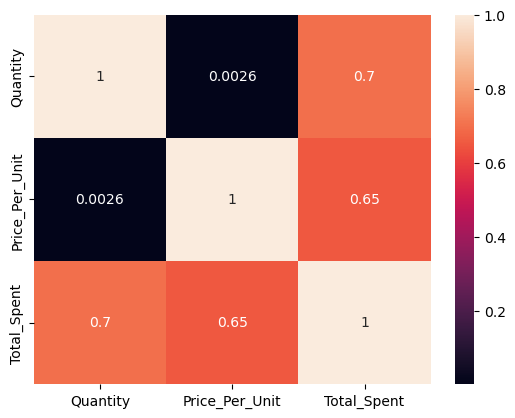

In [24]:
sns.heatmap(ds[['Quantity','Price_Per_Unit','Total_Spent']].corr(),annot=True)